# <b> Proyecciones </b>

 > Es una forma de tomar un vector `x` y encontrar la parte de ese vector que vive en una dirección o subespacio que es de nuestro interes 

 si proyectas x sobre un subespacio $S$ : $x = \hat{x} + r $ 
  - $ \hat{x} = proj_{s}{(x)}$ La proyección; La mejor aproximación posible a x usando solo vectores de S 
  - $r = x - \hat{x}$ residuo ; la parte que es ortogonal al subespacio
  - $ r \perp S $ el residuo es ortogonal a todo vector dentro del subespacio

Si el subespacio es una sola recta generada por un vector \(u\), entonces:
$$ \operatorname{proj}_u(x) = \frac{x^\top u}{u^\top u}u $$

La proyección toma de $x$ únicamente su componente en la dirección de $u$. Lo que sobra es la parte perpendicular.

Tu interpretación de “explicatividad + residual” es muy buena. En regresión lineal: $ y = \hat{y} + e $

- $ \hat{y}=X\hat{\beta} $  es la proyección de $y$ sobre el espacio columna de $X$: la parte explicada por los factores.
- $e$ es el residuo ortogonal: la parte que los factores lineales no explican.

<b> Otra Notacion </b> 
- La proyeccion del vector x sobre el vector a
$ x = x_{||}  + x_{\perp}  $
- $ x_{||} = proj_{a}{x}$ paralelo a a 
- $ x_{\perp} = x -  proj_{a}{x} $ ortogonal a a 

x = [4. 3.]
a = [2. 1.]
Componente paralela / proyección = [4.4 2.2]
Componente ortogonal / residuo = [-0.4  0.8]
Reconstrucción x_paralelo + x_ortogonal = [4. 3.]
Producto punto a @ x_ortogonal = -8.881784197001252e-16


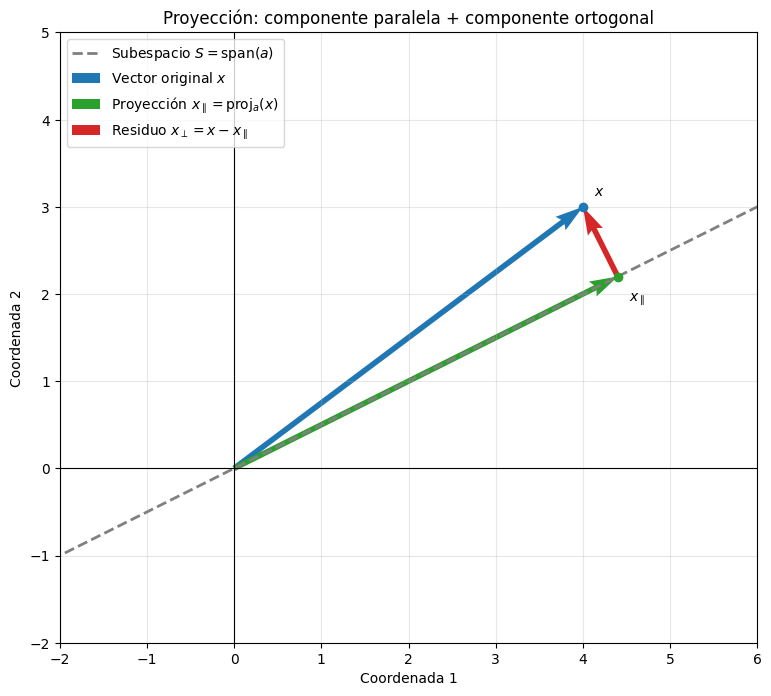

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Definimos los dos vectores en R^2
# ------------------------------------------------------------

# Vector que queremos descomponer
x = np.array([4.0, 3.0])

# Dirección que genera el subespacio S.
# En R^2, S es la recta que pasa por el origen y sigue a 'a'.
a = np.array([2.0, 1.0])

# ------------------------------------------------------------
# 2. Calculamos la proyección de x sobre la dirección a
# ------------------------------------------------------------

# Fórmula:
# proj_a(x) = [(x^T a) / (a^T a)] * a
#
# x @ a equivale a x^T a: producto punto.
# a @ a equivale a ||a||^2: norma al cuadrado.
x_paralelo = (x @ a) / (a @ a) * a

# El residuo es la parte que queda de x después de quitar
# la componente que sigue la dirección de a.
x_ortogonal = x - x_paralelo

# Comprobaciones geométricas
print("x =", x)
print("a =", a)
print("Componente paralela / proyección =", x_paralelo)
print("Componente ortogonal / residuo =", x_ortogonal)
print("Reconstrucción x_paralelo + x_ortogonal =", x_paralelo + x_ortogonal)
print("Producto punto a @ x_ortogonal =", a @ x_ortogonal)

# El último valor debe ser aproximadamente cero:
# a @ x_ortogonal ≈ 0
# Eso confirma que el residuo es perpendicular a la recta S.

# ------------------------------------------------------------
# 3. Función auxiliar para dibujar vectores como flechas
# ------------------------------------------------------------

def dibujar_vector(ax, inicio, vector, color, etiqueta):
    ax.quiver(
        inicio[0], inicio[1],
        vector[0], vector[1],
        angles="xy",
        scale_units="xy",
        scale=1,
        color=color,
        width=0.008,
        label=etiqueta
    )

# ------------------------------------------------------------
# 4. Gráfica geométrica de la descomposición
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 8))

# Recta S = span(a): todos los múltiplos de a
t = np.linspace(-2, 3, 100)
recta_S = np.outer(t, a)

ax.plot(
    recta_S[:, 0],
    recta_S[:, 1],
    color="gray",
    linestyle="--",
    linewidth=2,
    label=r"Subespacio $S = \mathrm{span}(a)$"
)

# Vector original: desde el origen hasta x
dibujar_vector(
    ax,
    inicio=np.array([0.0, 0.0]),
    vector=x,
    color="tab:blue",
    etiqueta=r"Vector original $x$"
)

# Proyección: desde el origen hasta x_paralelo
dibujar_vector(
    ax,
    inicio=np.array([0.0, 0.0]),
    vector=x_paralelo,
    color="tab:green",
    etiqueta=r"Proyección $x_{\parallel} = \mathrm{proj}_a(x)$"
)

# Residuo: va desde la punta de la proyección hasta la punta de x
dibujar_vector(
    ax,
    inicio=x_paralelo,
    vector=x_ortogonal,
    color="tab:red",
    etiqueta=r"Residuo $x_{\perp} = x - x_{\parallel}$"
)

# Segmento punteado que muestra la caída perpendicular a la recta S
ax.plot(
    [x_paralelo[0], x[0]],
    [x_paralelo[1], x[1]],
    linestyle=":",
    color="tab:red",
    linewidth=2
)

# Etiquetas de puntos importantes
ax.scatter(*x, color="tab:blue", zorder=3)
ax.scatter(*x_paralelo, color="tab:green", zorder=3)

ax.annotate(r"$x$", xy=x, xytext=(8, 8), textcoords="offset points")
ax.annotate(
    r"$x_{\parallel}$",
    xy=x_paralelo,
    xytext=(8, -18),
    textcoords="offset points"
)

# Formato visual
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_aspect("equal")
ax.set_xlim(-2, 6)
ax.set_ylim(-2, 5)
ax.set_xlabel("Coordenada 1")
ax.set_ylabel("Coordenada 2")
ax.set_title("Proyección: componente paralela + componente ortogonal")
ax.grid(alpha=0.3)
ax.legend(loc="upper left")

plt.show()